In [8]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from scipy.optimize import minimize

from src_renyi import (
    RBM_Z2,
    free_energy_minimize_scipy
)

In [9]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 2
N_ancilla = 2

hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [10]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

In [11]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)

T_array = np.linspace(0, 2, 30)
H_history = []
S_history = []
F_history = []

for t in T_array:
    vstate.init_parameters()

    result = free_energy_minimize_scipy(
        vstate=vstate,
        T=t,
        partition=list(range(N)),
        Hamiltonian=H_extended,
        method="BFGS",
        verbose=False,
    )

    F_history.append(result["best_F"])
    H_history.append(result["best_energy"])
    S_history.append(result["best_entropy"])
    print(f"T={t:.2f} | F={result['best_F']:.6f} | ¿Éxito?: {result['result'].success}")

T=0.00 | F=-3.605551 | ¿Éxito?: True
T=0.07 | F=-3.605551 | ¿Éxito?: True
T=0.14 | F=-3.605551 | ¿Éxito?: True
T=0.21 | F=-3.605551 | ¿Éxito?: True
T=0.28 | F=-3.605551 | ¿Éxito?: True
T=0.34 | F=-3.605551 | ¿Éxito?: True
T=0.41 | F=-3.605551 | ¿Éxito?: True
T=0.48 | F=-3.605551 | ¿Éxito?: True
T=0.55 | F=-3.605551 | ¿Éxito?: True
T=0.62 | F=-3.605551 | ¿Éxito?: True
T=0.69 | F=-3.605551 | ¿Éxito?: True
T=0.76 | F=-3.605551 | ¿Éxito?: True
T=0.83 | F=-3.609278 | ¿Éxito?: True
T=0.90 | F=-3.630320 | ¿Éxito?: True
T=0.97 | F=-3.658474 | ¿Éxito?: True
T=1.03 | F=-3.690677 | ¿Éxito?: True
T=1.10 | F=-3.725613 | ¿Éxito?: True
T=1.17 | F=-3.762543 | ¿Éxito?: True
T=1.24 | F=-3.800994 | ¿Éxito?: True
T=1.31 | F=-3.840644 | ¿Éxito?: True
T=1.38 | F=-3.881261 | ¿Éxito?: True
T=1.45 | F=-3.922675 | ¿Éxito?: True
T=1.52 | F=-3.964752 | ¿Éxito?: True
T=1.59 | F=-4.007390 | ¿Éxito?: True
T=1.66 | F=-4.050508 | ¿Éxito?: True
T=1.72 | F=-4.094039 | ¿Éxito?: True
T=1.79 | F=-4.137929 | ¿Éxito?: True
T

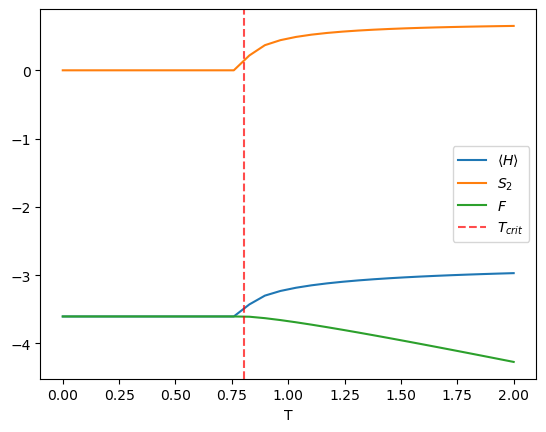

In [12]:
hamiltonian = np.array([
    [2*V, Gamma, Gamma, 0],
    [Gamma, -2*V, 0, Gamma],
    [Gamma, 0, -2*V, Gamma],
    [0, Gamma, Gamma, 2*V]
])

eig = np.linalg.eigvals(hamiltonian)
eig_2 = (np.sort(eig))[:2]
t_c = np.abs(eig_2[1]-eig_2[0])/2
plt.plot(T_array, H_history, label=r"$\langle H \rangle $")
plt.plot(T_array, S_history, label=r"$S_2$")
plt.plot(T_array, F_history, label=r"$F$")
plt.axvline(x=t_c, color='red', linestyle='--', alpha=0.7, label=r"$T_{crit}$")
plt.xlabel("T")
plt.legend()
plt.show()

There is a transtition a certain temperature $T_{crit}$, where $S_2$ stops being 0 and $\langle H \rangle$ starts increasing. Therefore, we can say that the system stops being in the ground state for $T=0$, and more states appear in our wavefunction. To see where $T_{crit}$ takes place, we can use the following ansatz for our wavefunction:
 
$$
|\Psi\rangle = \sqrt{1-p} |\phi_0\rangle \otimes |a_0\rangle + \sqrt{p} |\phi_1\rangle \otimes |a_1\rangle
$$

It is a Schmidt decomsition, using only the two lowest energy eigenstates because, close to $T_{crit}$ the population starts to migrate from $|\phi_0\rangle$ to $|\phi_1\rangle$ as $T$ increases.

The energy is 
$$
\langle H \rangle = (1-p)E_0 + pE_1
$$
And the energy variation from the ground state:
$$
\Delta E = \langle H \rangle -E_0 = p(E_1-E_0)
$$

We have chosen $\langle a_0|a_1\rangle =0$, so the reduced demsity matrix is 
$$
\rho_S = Tr_A(|\Psi\rangle\langle\Psi |) = (1-p)|\phi_0\rangle\langle\phi_0 | + p|\phi_1\rangle\langle\phi_1 |
$$
And the second order Rényi entropy:
$$
S_2 = -\ln(Tr(\rho_S^2)) = -\ln((1-p)^2+p^2)
$$

The free energy $F(T,p)$ is therefore:
$$
F(T,p) = \langle H \rangle - TS_2 = (1-p)E_0 + pE_1  +T\ln((1-p)^2+p^2)
$$
And, expanding up to order $p$
$$
F(T,p)  = E_0 + p(E_1-E_0)-T(2p)+\mathcal{O}(p^2)\approx E_0 + p(E_1-E_0)-T(2p)
$$

The pure ground state ($p=0$) is stable if $\frac{\partial F}{\partial p}\big|_{p=0} > 0 $:
$$
E_1 - E_0 -2T > 0 \Rightarrow T<\frac{E_1-E_0}{2}
$$
The trasition happens at $T_{crit}=\frac{E_1-E_0}{2}$.

In [13]:

G = np.linspace(-2, -0.5, 20)
T = np.linspace(0,2,40)
T_crit_history = []
T_crit_approx = []

for g in G:
    Gamma = g  
    V = -1
    H_extended = 0
    # S_history = []
    for i in range(N):
        H_extended += Gamma * sigmax(hi_extended, i)
        H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
    hamiltonian = np.array([
        [2*V, Gamma, Gamma, 0],
        [Gamma, -2*V, 0, Gamma],
        [Gamma, 0, -2*V, Gamma],
        [0, Gamma, Gamma, 2*V]
    ])
    eig = np.linalg.eigvals(hamiltonian)
    eig_2 = (np.sort(eig))[:2]
    t_c = np.abs(eig_2[1]-eig_2[0])/2
    T_crit_approx.append(t_c)

    for t in T:
        vstate.init_parameters()
        result = free_energy_minimize_scipy(
            vstate=vstate,
            T=t,
            partition=list(range(N)),
            Hamiltonian=H_extended,
            method="BFGS",
            verbose=False,
        )
        if result['best_entropy'] > 0.1:
            t_crit = t - (T[1]-T[0])
            break

    T_2 = np.linspace(t_crit, (t_crit+T[1]-T[0]), 15)
    for t in T_2:
        vstate.init_parameters()
        result = free_energy_minimize_scipy(
            vstate=vstate,
            T=t,
            partition=list(range(N)),
            Hamiltonian=H_extended,
            method="BFGS",
            verbose=False,
        )
        if result['best_entropy'] > 0.1:
            t_crit = t - (T_2[1]-T_2[0])
            break
    T_crit_history.append(t_crit)
    print(f"Gamma = {g:.2f}, T_crit =  {t_crit:.2f}, T_crit_approx = {t_c:.2f}")

Gamma = -2.00, T_crit =  1.24, T_crit_approx = 1.24
Gamma = -1.92, T_crit =  1.17, T_crit_approx = 1.17
Gamma = -1.84, T_crit =  1.10, T_crit_approx = 1.10
Gamma = -1.76, T_crit =  1.03, T_crit_approx = 1.03
Gamma = -1.68, T_crit =  0.96, T_crit_approx = 0.96
Gamma = -1.61, T_crit =  0.89, T_crit_approx = 0.89
Gamma = -1.53, T_crit =  0.83, T_crit_approx = 0.82
Gamma = -1.45, T_crit =  0.76, T_crit_approx = 0.76
Gamma = -1.37, T_crit =  0.70, T_crit_approx = 0.69
Gamma = -1.29, T_crit =  0.63, T_crit_approx = 0.63
Gamma = -1.21, T_crit =  0.57, T_crit_approx = 0.57
Gamma = -1.13, T_crit =  0.51, T_crit_approx = 0.51
Gamma = -1.05, T_crit =  0.45, T_crit_approx = 0.45
Gamma = -0.97, T_crit =  0.40, T_crit_approx = 0.40
Gamma = -0.89, T_crit =  0.34, T_crit_approx = 0.34
Gamma = -0.82, T_crit =  0.29, T_crit_approx = 0.29
Gamma = -0.74, T_crit =  0.24, T_crit_approx = 0.24
Gamma = -0.66, T_crit =  0.20, T_crit_approx = 0.20
Gamma = -0.58, T_crit =  0.15, T_crit_approx = 0.16
Gamma = -0.5

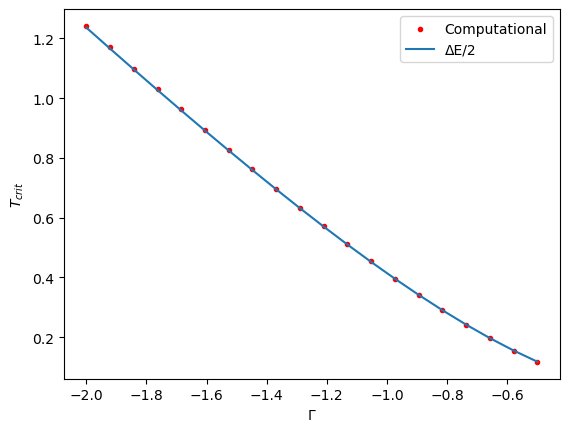

In [14]:
plt.scatter (G, T_crit_history, label="Computational", marker=".", color="red")
plt.plot (G, T_crit_approx, label="ΔE/2")
plt.xlabel(r"$\Gamma$")
plt.ylabel(r"$T_{crit}$") 
plt.legend()
plt.show()